# Climate Risk Exposure Analysis for Investment Portfolios

## 1. Project Objective
## 2. Import Libraries
## 3. Load Datasets
## 4. Explore the Data
## 5. Merge Portfolio and Emissions Data
## 6. Calculate Weighted Carbon Exposure
## 7. Analyze Portfolio Climate Risk
## 8. Visualize Results
## 9. Scenario Analysis: Rebalanced Portfolio
## 10. Conclusion

# Step 1 - Project Objective
* Assess Portfolio Carbon Exposure
Evaluate the carbon exposure of a sample investment portfolio by linking portfolio holdings with sector-level carbon intensity data.

* Identify High-Emission Sectors and Holdings
Determine which sectors and individual holdings contribute the most to the portfolio's overall climate risk.

* Calculate Weighted Carbon Exposure
Apply a weighted exposure methodology that combines portfolio allocation weights with sector carbon intensity values to estimate each holding’s contribution to total portfolio emissions.

* Visualize Climate Risk Distribution
Use data visualization techniques to illustrate how carbon exposure is distributed across sectors and portfolio holdings.

* Perform Scenario Analysis
Evaluate how changes in portfolio allocation—such as reducing exposure to high-carbon sectors—can impact the portfolio’s total climate risk.

* Demonstrate the Role of Climate Data in Portfolio Risk Management
Show how climate-related data can be integrated into financial portfolio analysis to support more sustainable investment decision-making.



# Step 2 — Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 3 — Load the CSV files

In [3]:
portfolio = pd.read_csv("portfolio_data.csv")
emissions = pd.read_csv("sector_emissions.csv")

# Step 4 — Preview the datasets

In [5]:
print("Portfolio Data:")
print(portfolio.head())

print("\nSector Emissions Data:")
print(emissions.head())

Portfolio Data:
          company     sector  portfolio_weight
0           Exxon     Energy              0.06
1         Chevron     Energy              0.05
2        Enbridge     Energy              0.05
3  NextEra Energy  Utilities              0.05
4     Duke Energy  Utilities              0.04

Sector Emissions Data:
                   sector  carbon_intensity
0                  Energy               450
1               Utilities               380
2             Industrials               250
3               Materials               220
4  Consumer Discretionary                90


# Step 5 — Check dataset structure

In [7]:
print(portfolio.info())
print(emissions.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   company           25 non-null     object 
 1   sector            25 non-null     object 
 2   portfolio_weight  25 non-null     float64
dtypes: float64(1), object(2)
memory usage: 732.0+ bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   sector            9 non-null      object
 1   carbon_intensity  9 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 276.0+ bytes
None


# Step 6 — Check for missing values

In [9]:
print("Missing values in portfolio data:")
print(portfolio.isnull().sum())

print("\nMissing values in emissions data:")
print(emissions.isnull().sum())

Missing values in portfolio data:
company             0
sector              0
portfolio_weight    0
dtype: int64

Missing values in emissions data:
sector              0
carbon_intensity    0
dtype: int64


# Step 7 Merge the two datasets

In [11]:
merged_df = pd.merge(portfolio, emissions, on="sector", how="left")
print(merged_df.head())

          company     sector  portfolio_weight  carbon_intensity
0           Exxon     Energy              0.06               450
1         Chevron     Energy              0.05               450
2        Enbridge     Energy              0.05               450
3  NextEra Energy  Utilities              0.05               380
4     Duke Energy  Utilities              0.04               380


# Step 8 — Calculate weighted carbon exposure
Formula:
weighted_carbon_exposure = portfolio_weight × carbon_intensity

In [13]:
merged_df["weighted_carbon_exposure"] = (
    merged_df["portfolio_weight"] * merged_df["carbon_intensity"]
)

print(merged_df.head())

          company     sector  portfolio_weight  carbon_intensity  \
0           Exxon     Energy              0.06               450   
1         Chevron     Energy              0.05               450   
2        Enbridge     Energy              0.05               450   
3  NextEra Energy  Utilities              0.05               380   
4     Duke Energy  Utilities              0.04               380   

   weighted_carbon_exposure  
0                      27.0  
1                      22.5  
2                      22.5  
3                      19.0  
4                      15.2  


# Step 9 — Calculate total portfolio climate exposure

In [15]:
total_exposure = merged_df["weighted_carbon_exposure"].sum()
print("Total Portfolio Climate Exposure:", total_exposure)

Total Portfolio Climate Exposure: 198.6


# Step 10 — Analyze climate exposure by sector

In [17]:
sector_exposure = (
    merged_df.groupby("sector")["weighted_carbon_exposure"]
    .sum()
    .sort_values(ascending=False)
)

print(sector_exposure)

sector
Energy                    72.0
Utilities                 34.2
Industrials               32.5
Materials                 22.0
Consumer Discretionary    11.7
Financials                10.2
Technology                 6.8
Healthcare                 6.0
Consumer Staples           3.2
Name: weighted_carbon_exposure, dtype: float64


# Step 11 — Analyze top holdings by climate exposure

In [19]:
top_holdings = merged_df.sort_values(
    by="weighted_carbon_exposure",
    ascending=False
)

print(top_holdings[["company", "sector", "portfolio_weight", "carbon_intensity", "weighted_carbon_exposure"]])

              company                  sector  portfolio_weight  \
0               Exxon                  Energy              0.06   
2            Enbridge                  Energy              0.05   
1             Chevron                  Energy              0.05   
3      NextEra Energy               Utilities              0.05   
4         Duke Energy               Utilities              0.04   
5         Caterpillar             Industrials              0.05   
6              Boeing             Industrials              0.04   
7                  3M             Industrials              0.04   
21                Dow               Materials              0.04   
23          Rio Tinto               Materials              0.03   
22   Freeport-McMoRan               Materials              0.03   
11             Amazon  Consumer Discretionary              0.05   
13         Home Depot  Consumer Discretionary              0.04   
12              Tesla  Consumer Discretionary              0.0

# Step 12 — Plot climate exposure by sector

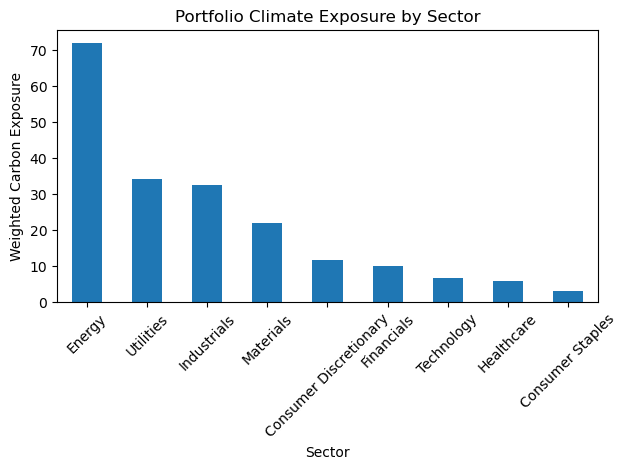

In [21]:
sector_exposure.plot(kind="bar")
plt.title("Portfolio Climate Exposure by Sector")
plt.xlabel("Sector")
plt.ylabel("Weighted Carbon Exposure")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 13 — Plot top 10 holdings by climate exposure

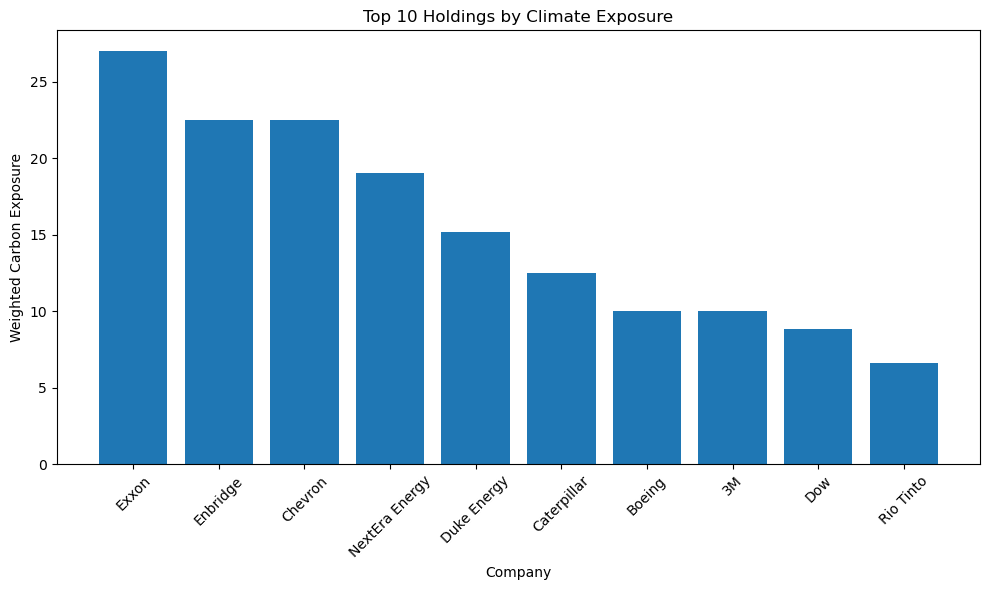

In [23]:
top_10 = top_holdings.head(10)

plt.figure(figsize=(10,6))
plt.bar(top_10["company"], top_10["weighted_carbon_exposure"])
plt.title("Top 10 Holdings by Climate Exposure")
plt.xlabel("Company")
plt.ylabel("Weighted Carbon Exposure")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 14 — Plot portfolio allocation by sector

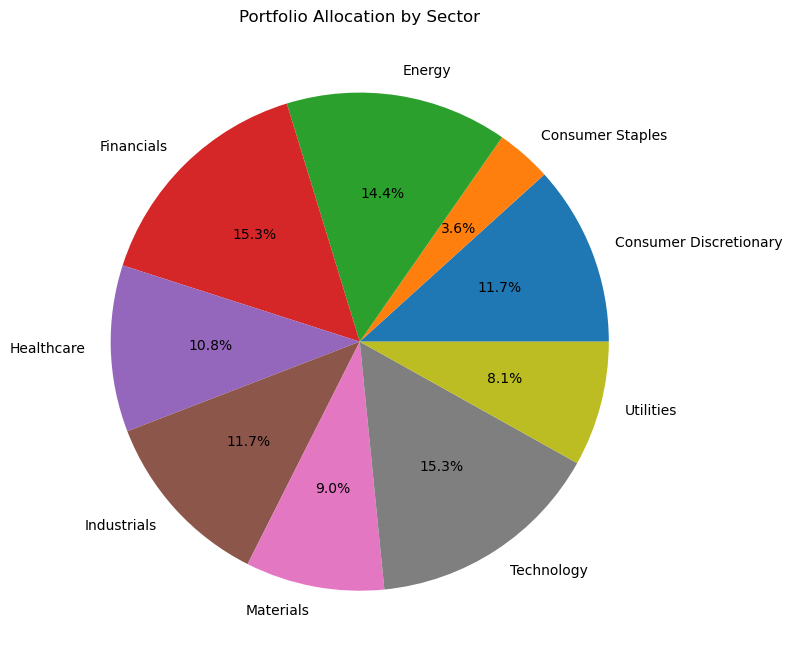

In [25]:
sector_weights = merged_df.groupby("sector")["portfolio_weight"].sum()

plt.figure(figsize=(8,8))
plt.pie(sector_weights, labels=sector_weights.index, autopct="%1.1f%%")
plt.title("Portfolio Allocation by Sector")
plt.tight_layout()
plt.show()

# Scenario Analysis

Now you will create a rebalanced portfolio with lower exposure to high-carbon sectors like Energy and Utilities.

# Step 15 — Create a rebalanced portfolio

In [27]:
rebalanced_data = {
    "company": [
        "Exxon", "Chevron", "Enbridge", "NextEra Energy", "Duke Energy",
        "Caterpillar", "Boeing", "3M", "Microsoft", "Apple", "Nvidia",
        "Amazon", "Tesla", "Home Depot", "JPMorgan", "Goldman Sachs",
        "Visa", "Mastercard", "Pfizer", "Johnson & Johnson", "UnitedHealth",
        "Dow", "Freeport-McMoRan", "Rio Tinto", "Procter & Gamble"
    ],
    "sector": [
        "Energy", "Energy", "Energy", "Utilities", "Utilities",
        "Industrials", "Industrials", "Industrials", "Technology", "Technology", "Technology",
        "Consumer Discretionary", "Consumer Discretionary", "Consumer Discretionary",
        "Financials", "Financials", "Financials", "Financials",
        "Healthcare", "Healthcare", "Healthcare",
        "Materials", "Materials", "Materials", "Consumer Staples"
    ],
    "portfolio_weight": [
        0.03, 0.03, 0.03, 0.03, 0.03,
        0.05, 0.04, 0.04, 0.08, 0.08, 0.07,
        0.05, 0.04, 0.04, 0.06, 0.05, 0.05, 0.05,
        0.05, 0.05, 0.05, 0.04, 0.03, 0.03, 0.05
    ]
}

rebalanced_portfolio = pd.DataFrame(rebalanced_data)
print(rebalanced_portfolio.head())

          company     sector  portfolio_weight
0           Exxon     Energy              0.03
1         Chevron     Energy              0.03
2        Enbridge     Energy              0.03
3  NextEra Energy  Utilities              0.03
4     Duke Energy  Utilities              0.03


# Step 16 — Merge rebalanced portfolio with emissions data

In [29]:
rebalanced_df = pd.merge(rebalanced_portfolio, emissions, on="sector", how="left")
print(rebalanced_df.head())

          company     sector  portfolio_weight  carbon_intensity
0           Exxon     Energy              0.03               450
1         Chevron     Energy              0.03               450
2        Enbridge     Energy              0.03               450
3  NextEra Energy  Utilities              0.03               380
4     Duke Energy  Utilities              0.03               380


# Step 17 — Calculate rebalanced weighted carbon exposure

In [31]:
rebalanced_df["weighted_carbon_exposure"] = (
    rebalanced_df["portfolio_weight"] * rebalanced_df["carbon_intensity"]
)

print(rebalanced_df.head())

          company     sector  portfolio_weight  carbon_intensity  \
0           Exxon     Energy              0.03               450   
1         Chevron     Energy              0.03               450   
2        Enbridge     Energy              0.03               450   
3  NextEra Energy  Utilities              0.03               380   
4     Duke Energy  Utilities              0.03               380   

   weighted_carbon_exposure  
0                      13.5  
1                      13.5  
2                      13.5  
3                      11.4  
4                      11.4  


# Step 18 — Compare original vs rebalanced portfolio

In [33]:
original_total = merged_df["weighted_carbon_exposure"].sum()
rebalanced_total = rebalanced_df["weighted_carbon_exposure"].sum()

print("Original Portfolio Exposure:", original_total)
print("Rebalanced Portfolio Exposure:", rebalanced_total)
print("Exposure Reduction:", original_total - rebalanced_total)

Original Portfolio Exposure: 198.6
Rebalanced Portfolio Exposure: 162.8
Exposure Reduction: 35.79999999999998


# Step 19 — Plot original vs rebalanced exposure

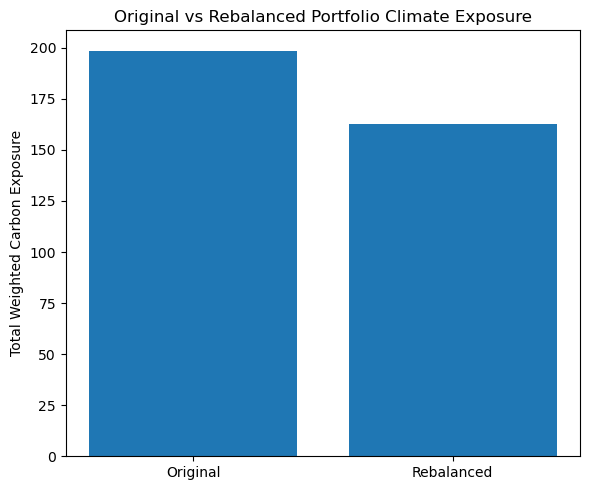

In [35]:
comparison = pd.DataFrame({
    "Portfolio": ["Original", "Rebalanced"],
    "Exposure": [original_total, rebalanced_total]
})

plt.figure(figsize=(6,5))
plt.bar(comparison["Portfolio"], comparison["Exposure"])
plt.title("Original vs Rebalanced Portfolio Climate Exposure")
plt.ylabel("Total Weighted Carbon Exposure")
plt.tight_layout()
plt.show()

In [37]:
merged_df.to_csv("portfolio_climate_analysis_output.csv", index=False)
rebalanced_df.to_csv("rebalanced_portfolio_climate_analysis_output.csv", index=False)

In [41]:
portfolio_carbon_intensity = merged_df["weighted_carbon_exposure"].sum() / merged_df["portfolio_weight"].sum()

print("Portfolio Carbon Intensity:", portfolio_carbon_intensity)

Portfolio Carbon Intensity: 178.9189189189189


In [43]:
merged_df["exposure_percentage"] = (
    merged_df["weighted_carbon_exposure"] /
    merged_df["weighted_carbon_exposure"].sum()
) * 100

top_emitters = merged_df.sort_values(
    by="exposure_percentage",
    ascending=False
)

print(top_emitters[["company","sector","exposure_percentage"]].head(10))

           company       sector  exposure_percentage
0            Exxon       Energy            13.595166
2         Enbridge       Energy            11.329305
1          Chevron       Energy            11.329305
3   NextEra Energy    Utilities             9.566969
4      Duke Energy    Utilities             7.653575
5      Caterpillar  Industrials             6.294058
6           Boeing  Industrials             5.035247
7               3M  Industrials             5.035247
21             Dow    Materials             4.431017
23       Rio Tinto    Materials             3.323263


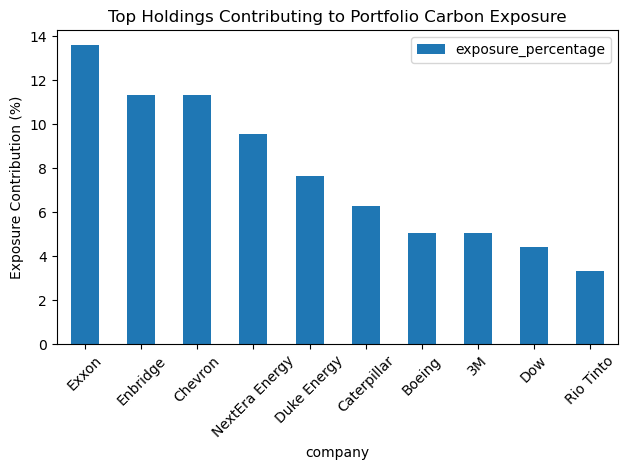

In [45]:
top_emitters.head(10).plot(
    x="company",
    y="exposure_percentage",
    kind="bar"
)

plt.title("Top Holdings Contributing to Portfolio Carbon Exposure")
plt.ylabel("Exposure Contribution (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 20 — Conclusions


This analysis shows that Energy and Utilities contribute disproportionately to total portfolio climate exposure because of their high sector carbon intensity.

Although Technology and Financials have meaningful portfolio weights, their contribution to climate exposure is much lower.

The rebalanced portfolio reduced total climate exposure by shifting weight away from high-carbon sectors and toward lower-carbon sectors such as Technology, Healthcare, and Financials.

This demonstrates how sector allocation decisions can significantly influence climate-related portfolio risk.

# Step 21 Define a carbon price 

$50 per ton of CO₂ 

# Step 22 — Calculate Carbon Cost

Formula:

Carbon Cost = Weighted Carbon Exposure × Carbon Price

In [47]:
carbon_price = 50

merged_df["carbon_cost"] = (
    merged_df["weighted_carbon_exposure"] * carbon_price
)

print(merged_df[["company","sector","carbon_cost"]].head())

          company     sector  carbon_cost
0           Exxon     Energy       1350.0
1         Chevron     Energy       1125.0
2        Enbridge     Energy       1125.0
3  NextEra Energy  Utilities        950.0
4     Duke Energy  Utilities        760.0


# Step 23 — Calculate Portfolio Carbon Cost

In [49]:
total_carbon_cost = merged_df["carbon_cost"].sum()

print("Estimated Portfolio Carbon Cost:", total_carbon_cost)

Estimated Portfolio Carbon Cost: 9930.0


# Step 24 — Identify Most Exposed Holdings

In [51]:
top_carbon_cost = merged_df.sort_values(
    by="carbon_cost",
    ascending=False
)

print(top_carbon_cost[["company","sector","carbon_cost"]].head(10))

           company       sector  carbon_cost
0            Exxon       Energy       1350.0
2         Enbridge       Energy       1125.0
1          Chevron       Energy       1125.0
3   NextEra Energy    Utilities        950.0
4      Duke Energy    Utilities        760.0
5      Caterpillar  Industrials        625.0
6           Boeing  Industrials        500.0
7               3M  Industrials        500.0
21             Dow    Materials        440.0
23       Rio Tinto    Materials        330.0


# Step 25 — Visualize Carbon Cost Risk

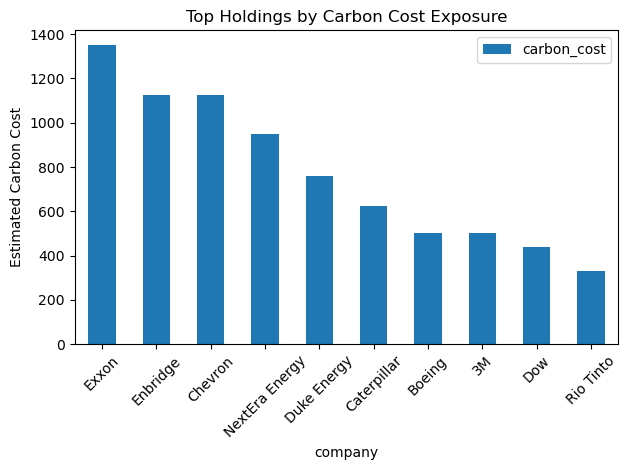

In [53]:
top_carbon_cost.head(10).plot(
    x="company",
    y="carbon_cost",
    kind="bar"
)

plt.title("Top Holdings by Carbon Cost Exposure")
plt.ylabel("Estimated Carbon Cost")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 26 Insight of Conclusion : 

The stress test analysis shows that high-carbon sectors such as Energy and Utilities would face the largest cost increases under a carbon pricing scenario. This highlights the potential financial impact of climate policy on portfolio holdings and demonstrates how carbon exposure can translate into economic risk for investors.